In [22]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Training and Testing Analysis

## 1. Training Analysis

In [23]:
training_history = pd.read_json(r'../../models/checkpoints/efficient_mamba/history_best_model_efficient_mamba.json')
training_history.columns

Index(['train_loss', 'train_acc', 'val_loss', 'val_acc'], dtype='object')

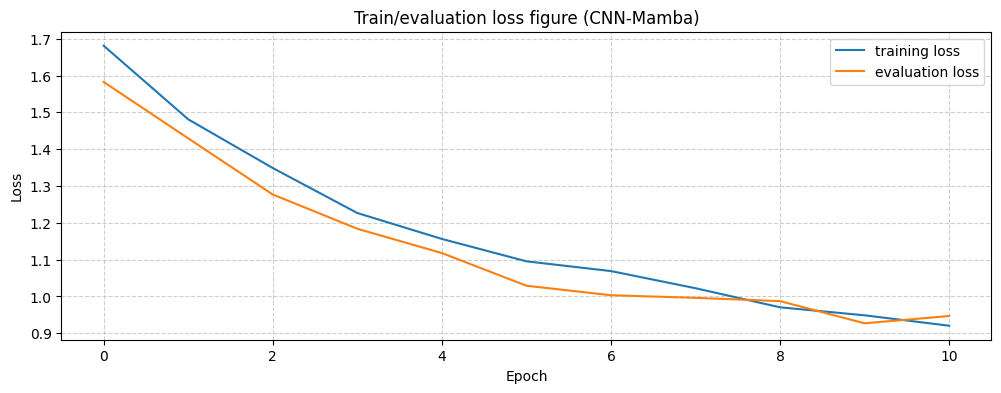

In [24]:
plt.figure(figsize=(12, 4))
plt.plot(training_history['train_loss'], label = 'training loss')
plt.plot(training_history['val_loss'], label = 'evaluation loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train/evaluation loss figure (CNN-Mamba)')
plt.grid(alpha=0.6, linestyle='--')
plt.legend()
plt.savefig('../../img/training_result/mamba/training_evaluation_loss.png')

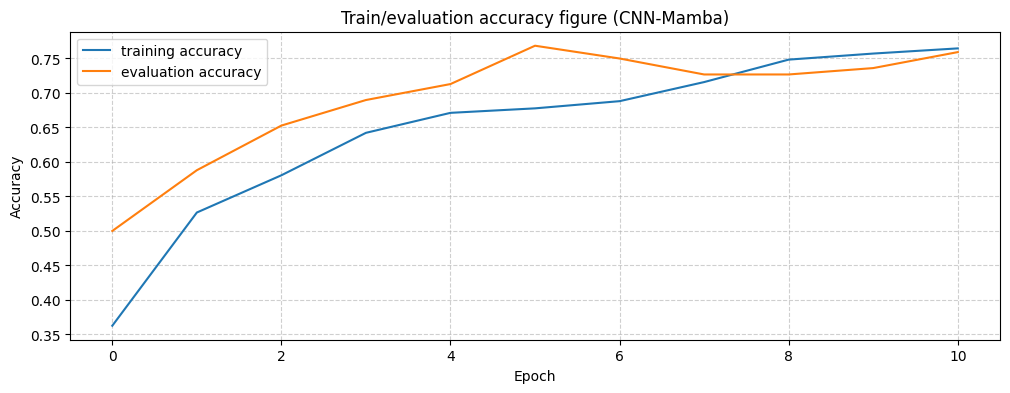

In [25]:
plt.figure(figsize=(12, 4))
plt.plot(training_history['train_acc'], label = 'training accuracy')
plt.plot(training_history['val_acc'], label = 'evaluation accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train/evaluation accuracy figure (CNN-Mamba)')
plt.grid(alpha=0.6, linestyle='--')
plt.legend()
plt.savefig('../../img/training_result/mamba/training_evaluation_accuracy.png')

## 2. Testing Analysis

In [26]:
result_path = r'..\..\models\checkpoints\efficient_mamba\eval_results\predictions_full.csv'
result = pd.read_csv(result_path)
print(result.head())

   True_ID  Pred_ID  True_Label  Pred_Label  Confidence  Correct
0        0        0  brush_hair  brush_hair      0.3878     True
1        0        5  brush_hair        walk      0.6244    False
2        0        0  brush_hair  brush_hair      0.2406     True
3        0        0  brush_hair  brush_hair      0.3559     True
4        0        0  brush_hair  brush_hair      0.7043     True


### 2.1. Confusion Matrix

In [ ]:
def plot_cm_with_analysis(df, error_ratio_threshold=0.2):
    classes = sorted(df['True_Label'].unique())
    cm = confusion_matrix(df['True_Label'], df['Pred_Label'], labels=classes)
    cm_sum = np.sum(cm, axis=1, keepdims=True)
    cm_perc = np.divide(cm.astype('float'), cm_sum, out=np.zeros_like(cm.astype('float')), where=cm_sum!=0) * 100

    print("="*80)
    print(f"ANALYSIS: MISCLASSIFICATIONS VS. CORRECT PREDICTIONS (Threshold: >={error_ratio_threshold*100}%)")
    print("="*80)
    
    found_any = False
    for i, class_name in enumerate(classes):
        correct_count = cm[i, i] 
        
        major_errors = []
        for j, pred_name in enumerate(classes):
            if i == j: continue
            
            wrong_count = cm[i, j]
            if wrong_count == 0: continue
            
            if correct_count == 0:
                ratio = float('inf')
                major_errors.append(f"{pred_name} (Count: {wrong_count}, Ratio: INF)")
            else:
                ratio = wrong_count / correct_count
                if ratio >= error_ratio_threshold:
                    major_errors.append(f"{pred_name} (Count: {wrong_count}, Ratio: {ratio:.2f})")
        
        if major_errors:
            found_any = True
            header = f"❌ {class_name:15} [Correct: {correct_count}]"
            print(f"{header} | Over-threshold errors: {', '.join(major_errors)}")
    
    if not found_any:
        print(f" Your model is solid. No error type exceeds {error_ratio_threshold*100}% of the correct predictions.")
    print("="*80 + "\n")

    plt.figure(figsize=(14, 11))
    annot = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            c, p = cm[i, j], cm_perc[i, j]
            annot[i, j] = f'{c}\n({p:.1f}%)' if c > 0 else '0'
    
    sns.heatmap(cm_perc, annot=annot, fmt='', cmap='Blues', xticklabels=classes, yticklabels=classes)
    
    plt.title('Confusion Matrix Analysis (CNN-Mamba)', fontsize=18, fontweight='bold', pad=20)
    plt.ylabel('True label', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted label', fontsize=14, fontweight='bold')

    plt.savefig('../../img/training_result/mamba/confusion_matrix.png')
    plt.show()

ANALYSIS: MISCLASSIFICATIONS VS. CORRECT PREDICTIONS (Threshold: >=50.0%)
❌ fall_floor      [Correct: 11] | Over-threshold errors: walk (Count: 7, Ratio: 0.64)



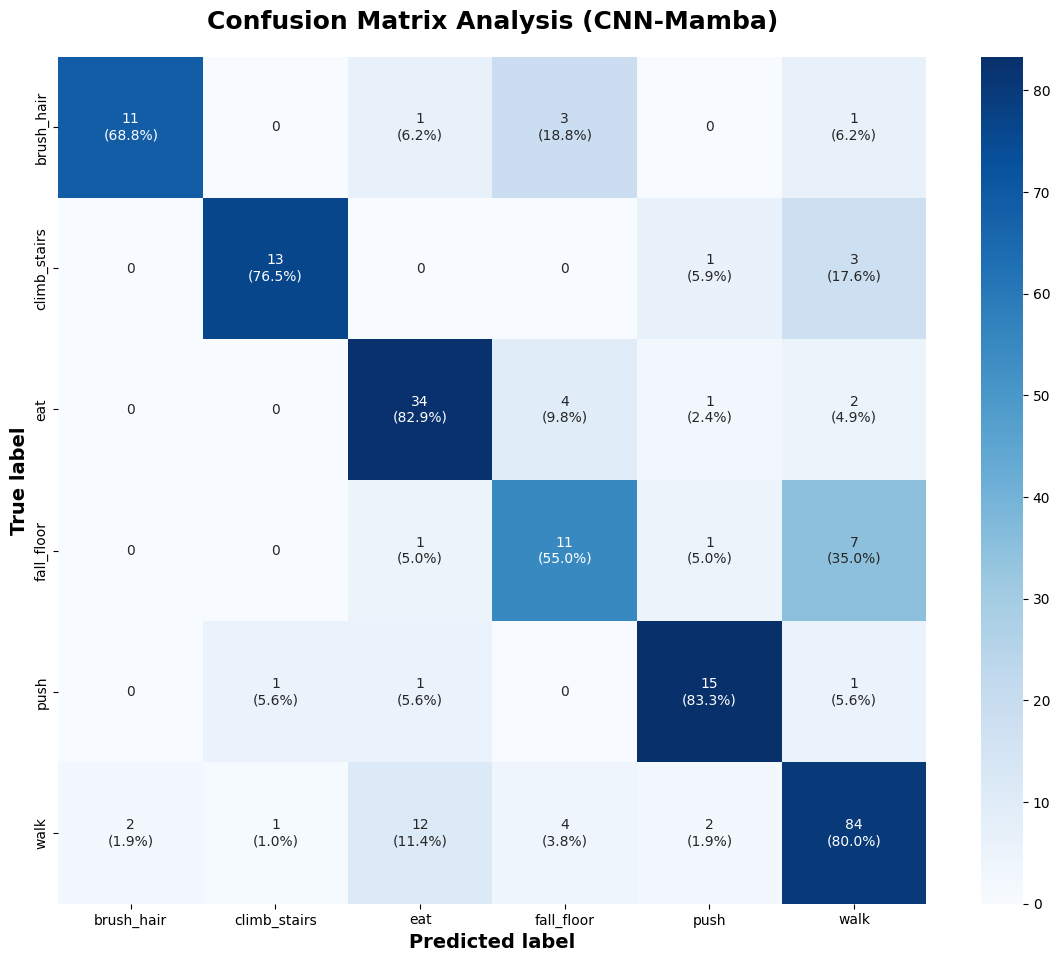

In [28]:
plot_cm_with_analysis(result, error_ratio_threshold=0.5)

### 2.2. Inference result analysis

In [29]:
from sklearn.metrics import f1_score, classification_report

f1_weighted = f1_score(result['True_Label'], result['Pred_Label'], average='weighted')

f1_per_class = f1_score(result['True_Label'], result['Pred_Label'], average=None)

In [30]:
print(f"F1-Score (Weighted): {f1_weighted:.4f}")
print("-" * 30)
print("Detailed report:")
report = classification_report(result['True_Label'], result['Pred_Label'])
print(report)

F1-Score (Weighted): 0.7766
------------------------------
Detailed report:
              precision    recall  f1-score   support

  brush_hair       0.85      0.69      0.76        16
climb_stairs       0.87      0.76      0.81        17
         eat       0.69      0.83      0.76        41
  fall_floor       0.50      0.55      0.52        20
        push       0.75      0.83      0.79        18
        walk       0.86      0.80      0.83       105

    accuracy                           0.77       217
   macro avg       0.75      0.74      0.74       217
weighted avg       0.78      0.77      0.78       217



## 3. Conclusion

### 3.1. Training

The training curves demonstrate a highly stable process with `no overfitting`, characterized by validation metrics initially outperforming training metrics due to aggressive regularization. While the convergence in the final epochs and the scheduler-induced loss reduction at epoch 20 indicate a healthy progression, `the accuracy plateau at 0.77` suggests a performance ceiling. Consequently, reducing regularization strength is necessary to break this threshold in future iterations.

### 3.2. Inference result

#### 3.2.1. Strength

- **Weighted Loss Impact**: Significantly improved Recall for underrepresented classes (e.g., brush_hair, drink).
- **Top Performance (brush_hair)**: Achieved high F1-score (`~0.83`), demonstrating strong capability in learning distinctive motion patterns.

#### 3.2.2. Weakness

- Low f1-score with fall-floor